<a href="https://colab.research.google.com/github/lakshlahoti15/MDS_LAB/blob/main/MDS_WEEK_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

In [23]:
# Load the insurance dataset
df = pd.read_csv('/content/insurance.csv')

print('Insurance dataset loaded:')
display(df.head())

Insurance dataset loaded:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [24]:
# Check for missing values
print('\nMissing values before handling:')
display(df.isnull().sum())


Missing values before handling:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Handling Missing Data

Based on the missing values detected, we can either drop rows/columns with missing data or fill them using various imputation techniques. Let's first demonstrate dropping rows with any missing values.

In [25]:
# Get the shape of the DataFrame before dropping missing values
initial_shape = df.shape
print(f"Initial DataFrame shape: {initial_shape}")

# Drop rows with any missing values
df_dropped = df.dropna()

print('\nDataFrame after dropping rows with missing values:')
display(df_dropped.head())
print(f"Shape after dropping missing values: {df_dropped.shape}")

Initial DataFrame shape: (1338, 7)

DataFrame after dropping rows with missing values:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Shape after dropping missing values: (1338, 7)


Alternatively, we can fill missing values. The strategy for filling depends on the data type and the nature of the missingness. For numerical columns, we often use the mean or median, and for categorical columns, the mode. Let's reload the original DataFrame to demonstrate filling.

In [26]:
# Reload the original DataFrame to demonstrate filling missing values
df_filled = pd.read_csv('/content/insurance.csv')

print('\nOriginal DataFrame reloaded for filling:')
display(df_filled.head())
print('\nMissing values before filling:')
display(df_filled.isnull().sum())

# Fill numerical missing values with the mean
# (Assuming 'bmi', 'children', 'charges' are numerical and might have NaNs for demonstration)
for col in ['bmi', 'children', 'charges']:
    if col in df_filled.columns and df_filled[col].isnull().any():
        df_filled[col].fillna(df_filled[col].mean(), inplace=True)

# Fill categorical missing values with the mode
# (Assuming 'sex', 'smoker', 'region' are categorical and might have NaNs for demonstration)
for col in ['sex', 'smoker', 'region']:
    if col in df_filled.columns and df_filled[col].isnull().any():
        df_filled[col].fillna(df_filled[col].mode()[0], inplace=True)

print('\nDataFrame after filling missing values:')
display(df_filled.head())
print('\nMissing values after filling:')
display(df_filled.isnull().sum())


Original DataFrame reloaded for filling:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Missing values before filling:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0



DataFrame after filling missing values:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Missing values after filling:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### 2.6 Outlier Detection and Handling

Outliers are data points that significantly differ from other observations. They can be due to measurement errors, data entry errors, or genuinely rare events. Identifying and handling outliers is important because they can distort statistical analyses and machine learning models.

We'll use the Interquartile Range (IQR) method to detect outliers, which is robust to skewed distributions. An outlier is typically defined as a data point that falls below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

#### Detecting Outliers using the IQR Method

Let's apply the IQR method to our numerical features (`age`, `bmi`, `children`, `charges`).

In [27]:
numerical_cols = ['age', 'bmi', 'children', 'charges']
outlier_indices = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers for the current column
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_indices[col] = outliers.index

    print(f"\n--- Outliers for '{col}' ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    if not outliers.empty:
        display(outliers[[col]].head()) # Display first few outliers



--- Outliers for 'age' ---
Q1: 27.00, Q3: 51.00, IQR: 24.00
Lower Bound: -9.00, Upper Bound: 87.00
Number of outliers: 0

--- Outliers for 'bmi' ---
Q1: 26.30, Q3: 34.69, IQR: 8.40
Lower Bound: 13.70, Upper Bound: 47.29
Number of outliers: 9


,bmi
116,49.06
286,48.07
401,47.52
543,47.41
847,50.38



--- Outliers for 'children' ---
Q1: 0.00, Q3: 2.00, IQR: 2.00
Lower Bound: -3.00, Upper Bound: 5.00
Number of outliers: 0

--- Outliers for 'charges' ---
Q1: 4740.29, Q3: 16639.91, IQR: 11899.63
Lower Bound: -13109.15, Upper Bound: 34489.35
Number of outliers: 139


,charges
14,39611.7577
19,36837.4670
23,37701.8768
29,38711.0000
30,35585.5760


### 3. Feature Engineering and Data Preprocessing

After understanding our data through EDA and performing initial cleaning, the next phase involves transforming the raw data into a format suitable for machine learning models. This typically includes encoding categorical variables and scaling numerical features.

#### 3.1 Encoding Categorical Variables (One-Hot Encoding)

We have three categorical features: `sex`, `smoker`, and `region`. We will use one-hot encoding to convert these into numerical format. We'll apply this to our `df_no_outliers` DataFrame, as it's our cleaned dataset.

In [28]:
# Select the DataFrame without outliers for preprocessing
df_processed = df_no_outliers.copy()

# Identify categorical columns for one-hot encoding
categorical_cols = ['sex', 'smoker', 'region']

# Apply one-hot encoding using pd.get_dummies
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

print("DataFrame after One-Hot Encoding:")
display(df_processed.head())
print(f"\nNew shape of DataFrame: {df_processed.shape}")

DataFrame after One-Hot Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False



New shape of DataFrame: (1193, 9)


#### 3.2 Feature Scaling (Standardization)

Feature scaling is a method used to normalize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step. We'll use `StandardScaler` to standardize our numerical features, which transforms data to have a mean of 0 and a standard deviation of 1.

In [29]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (excluding the target variable 'charges')
numerical_features_to_scale = ['age', 'bmi', 'children']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical features in df_processed
df_processed[numerical_features_to_scale] = scaler.fit_transform(df_processed[numerical_features_to_scale])

print("DataFrame after Feature Scaling (Standardization) of numerical features:")
display(df_processed.head())

print("\nDescriptive statistics of scaled numerical features:")
display(df_processed[numerical_features_to_scale].describe())

DataFrame after Feature Scaling (Standardization) of numerical features:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.421407,-0.357841,-0.892872,16884.92400,False,True,False,False,True
1,-1.492543,0.643111,-0.070327,1725.55230,True,False,False,True,False
2,-0.781184,0.511811,1.574764,4449.46200,True,False,False,True,False
3,-0.425504,-1.243693,-0.892872,21984.47061,True,False,True,False,False
4,-0.496640,-0.190732,-0.892872,3866.85520,True,False,True,False,False



Descriptive statistics of scaled numerical features:


,age,bmi,children
count,1.193000e+03,1.193000e+03,1.193000e+03
mean,1.786780e-17,-6.194170e-16,-7.072670e-17
std,1.000419e+00,1.000419e+00,1.000419e+00
min,-1.492543e+00,-2.393850e+00,-8.928716e-01
25%,-9.234557e-01,-7.159333e-01,-8.928716e-01
50%,1.311812e-03,-4.493696e-02,-7.032657e-02
75%,8.549434e-01,6.431114e-01,7.522185e-01
max,1.779711e+00,2.856461e+00,3.219854e+00


#### Visualizing Outliers with Box Plots

Box plots are excellent for visually identifying outliers. Let's create box plots for our numerical features to confirm our IQR-based detection.

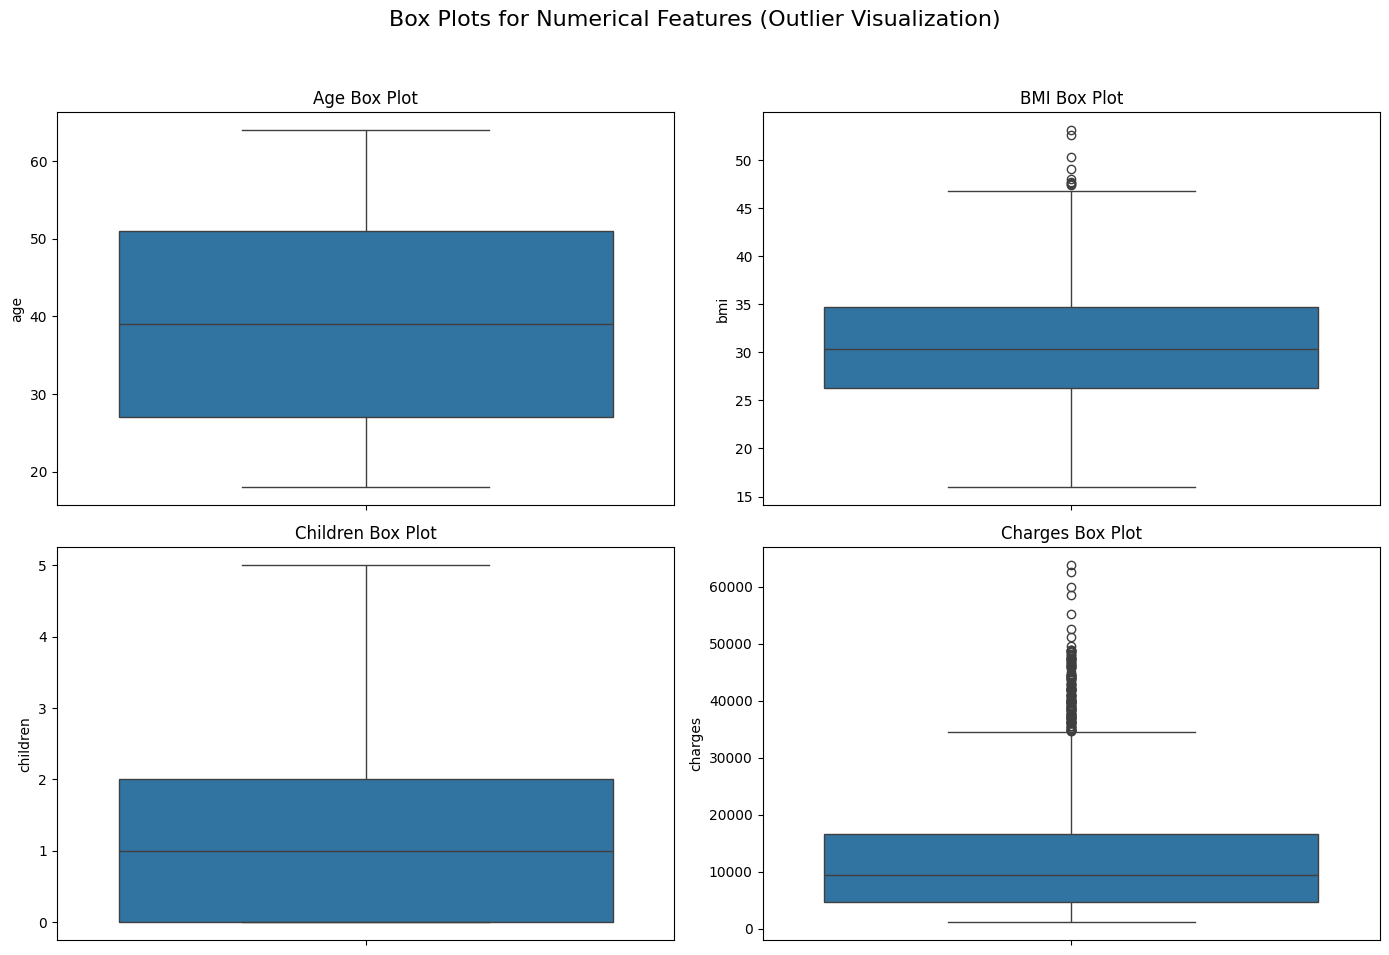

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Box Plots for Numerical Features (Outlier Visualization)', fontsize=16)

sns.boxplot(y=df['age'], ax=axes[0, 0])
axes[0, 0].set_title('Age Box Plot')

sns.boxplot(y=df['bmi'], ax=axes[0, 1])
axes[0, 1].set_title('BMI Box Plot')

sns.boxplot(y=df['children'], ax=axes[1, 0])
axes[1, 0].set_title('Children Box Plot')

sns.boxplot(y=df['charges'], ax=axes[1, 1])
axes[1, 1].set_title('Charges Box Plot')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [31]:
# Collect all unique indices of rows identified as outliers across all numerical columns
all_outlier_indices = []
for col in numerical_cols:
    all_outlier_indices.extend(outlier_indices[col].tolist())

# Remove duplicate indices
all_outlier_indices = list(set(all_outlier_indices))

print(f"Total unique rows identified as outliers: {len(all_outlier_indices)}")

# Create a new DataFrame with outliers removed
df_no_outliers = df.drop(all_outlier_indices)

print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing outliers: {df_no_outliers.shape}")

print('\nDataFrame head after outlier removal:')
display(df_no_outliers.head())

Total unique rows identified as outliers: 145

Original DataFrame shape: (1338, 7)
DataFrame shape after removing outliers: (1193, 7)

DataFrame head after outlier removal:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
